# Gyaradax Verification

Run `gksolve` on GKW standard test cases and compare growth rates
against GKW reference data in `tests/data/gkw_cases/`.

| Case | Geometry | Species | $n_{ky}$ | $q$ | $\hat{s}$ | $\varepsilon$ | $R/L_T$ |
|------|----------|---------|----------|-----|-----------|---------------|---------|
| `eiv_simple` | s-alpha | adiabatic | 1 | 1.4 | 0.78 | 0.19 | 6.9 |
| `slab_itg` | slab_periodic | adiabatic | 1 | 1.0 | 1.0 | 1.0 | 9.0 |
| `geom_circ` | circ | kinetic | 1 | 2.0 | 1.0 | 0.16 | 9.0 |
| `sourcetime` | circ | adiabatic | 4 | 1.4 | 0.78 | 0.19 | 5.0 |

**Note on flux comparison**: GKW reference fluxes are from an eigenvalue
solver at unit-normalized amplitude.  Our initial-value solver runs at a
different amplitude, so raw flux magnitudes differ.  Growth rates are the
meaningful comparison for linear cases.

In [1]:
import sys

sys.path.append("..")

from gyaradax.bootstrap import init_jax

init_jax(device=5)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


In [2]:
import os
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from gyaradax.plot_utils import (
    plot_flux_trace,
    plot_spectra,
    JAX_COLORS,
    SPECIES_COLORS,
)
from gyaradax.geometry import compute_geometry_from_input, geometry_from_geom_dat_and_input
from gyaradax.params import gkparams_from_input_and_geometry, load_config
from gyaradax.simulate import gk_init, gk_run
from gyaradax.solver import linear_precompute
from gyaradax.utils import parse_input_dat, load_geom_dat_file, load_geometry

GKW_CASES = os.path.join("..", "tests", "data", "gkw_cases")
os.makedirs("figs", exist_ok=True)

CIRC_GEOM_TYPES = {"circ", "s-alpha", ""}


def geom_type(case_name):
    """detect geometry type from input.dat. GKW defaults to s-alpha."""
    inp = parse_input_dat(os.path.join(GKW_CASES, case_name, "input.dat"))
    return inp.get("geom", {}).get("geom_type", "s-alpha").strip("'\"").lower()


def build_case(case_name):
    """build geometry + params from input.dat, with geom.dat fallback."""
    input_dat = os.path.join(GKW_CASES, case_name, "input.dat")
    gt = geom_type(case_name)
    geom_dat = os.path.join(GKW_CASES, case_name, "reference", "geom.dat")

    if gt in CIRC_GEOM_TYPES:
        geometry = compute_geometry_from_input(input_dat)
    elif os.path.exists(geom_dat):
        geometry = geometry_from_geom_dat_and_input(input_dat)
    else:
        raise ValueError(f"geometry type '{gt}' not supported and no geom.dat")

    params = gkparams_from_input_and_geometry(input_dat, geometry)

    # for kinetic electrons, copy species arrays from params into geometry
    if not params.adiabatic_electrons:
        for k in ("mas", "tmp", "de", "signz", "vthrat", "rlt", "rln"):
            val = getattr(params, k)
            geometry[k] = jnp.atleast_1d(jnp.asarray(val, dtype=jnp.float64))

    return geometry, params

---
# 1. Solver Verification

For each GKW standard test case: build geometry from `input.dat`, initialize
with `init_f`, run `gksolve` for the reference duration, and compare the
resulting fluxes and growth rates against `fluxes.dat` / `time.dat`.

In [14]:
import time as _time
from dataclasses import replace
from gyaradax.solver import gksolve, init_f, default_state

RUN_CASES = {
    "eiv_simple": {"desc": "CBC eigenvalue (s-alpha)", "n_windows": 1000},
    "slab_itg": {"desc": "slab ITG (slab_periodic)", "n_windows": 50, "dt_override": 0.01},
    "geom_circ": {"desc": "circular kinetic (circ)", "n_windows": 10},
}
SKIP_CASES = ["miller_mb", "kinetic_elec"]

results = {}
for case_name, info in RUN_CASES.items():
    ref_dir = os.path.join(GKW_CASES, case_name, "reference")
    time_path = os.path.join(ref_dir, "time.dat")
    flux_path = os.path.join(ref_dir, "fluxes.dat")

    print(f"\n{'='*60}")
    print(f"{case_name} — {info['desc']}")

    try:
        geometry, params = build_case(case_name)
    except Exception as e:
        print(f"  geometry build failed: {e}")
        continue

    if "dt_override" in info:
        params = replace(params, dt=info["dt_override"])

    gt = geom_type(case_name)
    nkx, nky = len(geometry["kxrh"]), len(geometry["krho"])
    print(f"  geom_type={gt}, nkx={nkx}, nky={nky}, dt={params.dt}, navg={params.naverage}")

    n_species = 1 if params.adiabatic_electrons else int(jnp.asarray(params.mas).shape[0])

    try:
        df, geometry, state = gk_init(geometry, params, n_species=n_species)
        pre = linear_precompute(geometry, params)
    except Exception as e:
        print(f"  init failed: {e}")
        continue

    n_windows = info["n_windows"]
    navg = params.naverage
    growth_hist, flux_hist, time_hist = [], [], []

    print(f"  running {n_windows} x {navg} steps...")
    t0 = _time.time()
    try:
        for i in range(n_windows):
            df, phi, fluxes, state = gk_run(df, geometry, params, state, navg, pre=pre)
            gr = np.asarray(state.last_growth_rate)
            growth_hist.append(gr)
            flux_hist.append(np.asarray(fluxes))
            time_hist.append(float(state.time))
            if not np.all(np.isfinite(gr)):
                print(f"  diverged at window {i+1}")
                break
        wall = _time.time() - t0
        print(f"  done in {wall:.1f}s ({n_windows * navg / wall:.0f} steps/s)")
    except Exception as e:
        print(f"  solver error: {e}")
        wall = _time.time() - t0

    ref_time = np.loadtxt(time_path) if os.path.exists(time_path) else None
    ref_fluxes = np.loadtxt(flux_path) if os.path.exists(flux_path) else None
    if ref_time is not None and ref_time.ndim == 1:
        ref_time = ref_time.reshape(1, -1)
    if ref_fluxes is not None and ref_fluxes.ndim == 1:
        ref_fluxes = ref_fluxes.reshape(1, -1)

    results[case_name] = {
        "growth": np.array(growth_hist),
        "fluxes": np.array(flux_hist) if flux_hist else np.array([]),
        "time": np.array(time_hist),
        "ref_time": ref_time,
        "ref_fluxes": ref_fluxes,
    }

    if len(growth_hist) > 10:
        avg_gamma = np.mean(np.abs(growth_hist[-10:]), axis=0)
        print(f"  |gamma| (last 10 avg): {np.mean(avg_gamma):.5f}")
        if ref_time is not None and ref_time.shape[1] >= 2:
            ref_g = np.abs(ref_time[-1, 1])
            err = abs(np.mean(avg_gamma) - ref_g) / ref_g * 100
            print(f"  GKW ref |gamma|:       {ref_g:.5f}  (err: {err:.1f}%)")

for case_name in SKIP_CASES:
    print(f"\n{case_name}: skipped (miller geometry)")


eiv_simple — CBC eigenvalue (s-alpha)
  geom_type=s-alpha, nkx=1, nky=1, dt=0.01, navg=1
  running 1000 x 1 steps...
  done in 1.7s (588 steps/s)
  |gamma| (last 10 avg): 0.20389
  GKW ref |gamma|:       0.18189  (err: 12.1%)

slab_itg — slab ITG (slab_periodic)
  geom_type=slab_periodic, nkx=9, nky=1, dt=0.01, navg=200
  running 50 x 200 steps...
  done in 2.2s (4525 steps/s)
  |gamma| (last 10 avg): 0.00022
  GKW ref |gamma|:       0.07258  (err: 99.7%)

geom_circ — circular kinetic (circ)
  geom_type=circ, nkx=1, nky=1, dt=0.0015, navg=10
  running 10 x 10 steps...
  done in 0.1s (759 steps/s)

miller_mb: skipped (miller geometry)

kinetic_elec: skipped (miller geometry)


## Flux and growth rate comparison

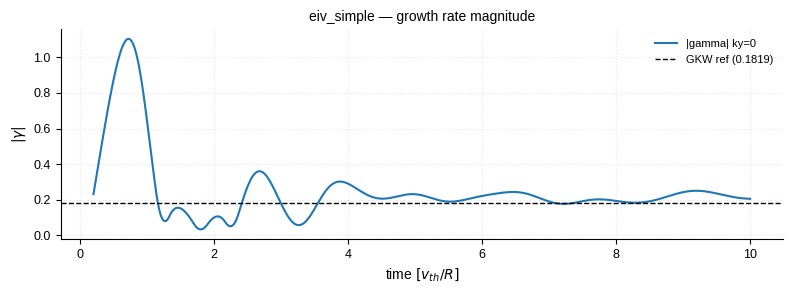

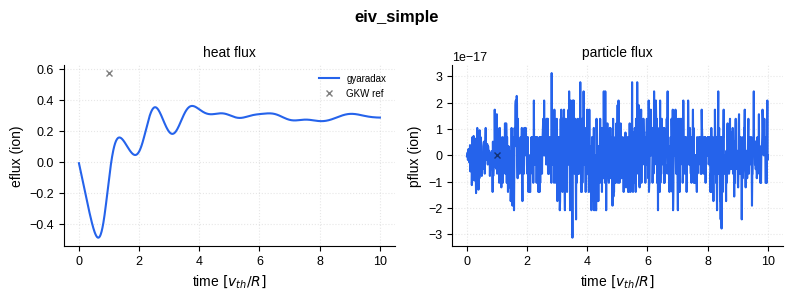

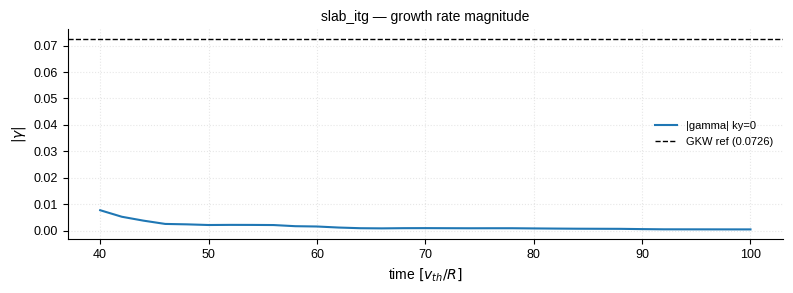

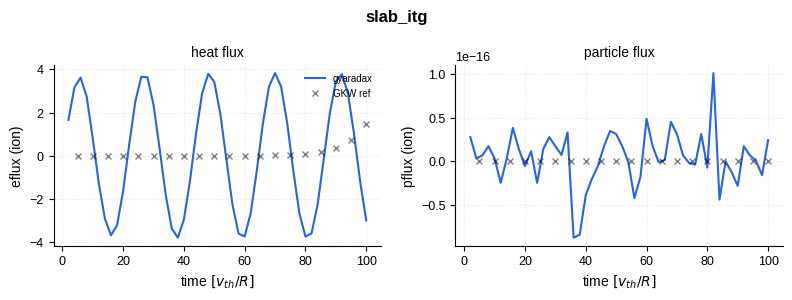

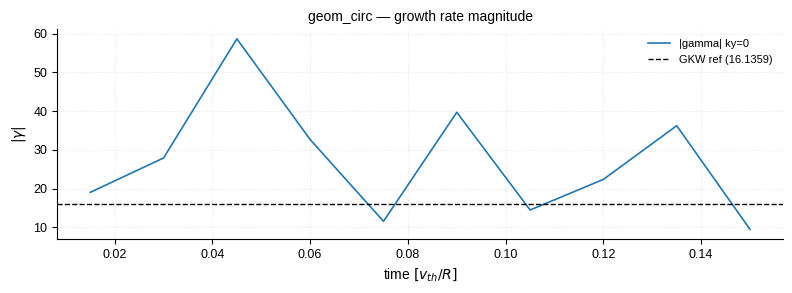

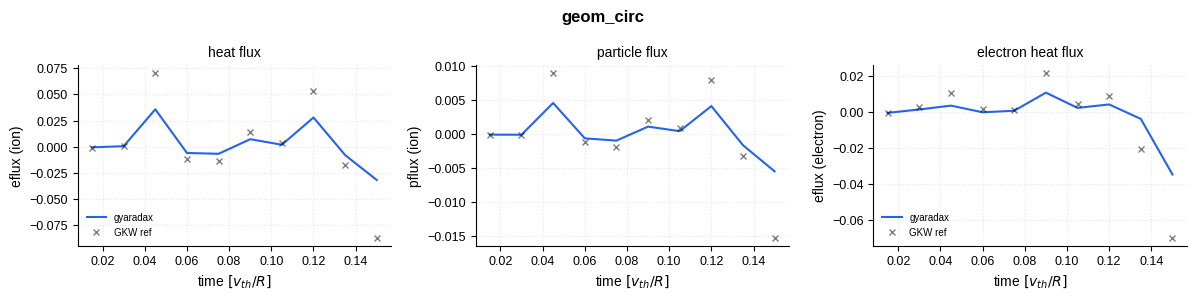

In [15]:
for case_name, res in results.items():
    sim_time = res["time"]
    sim_growth = res["growth"]
    sim_fluxes = res["fluxes"]
    ref_time = res["ref_time"]
    ref_fluxes = res["ref_fluxes"]

    if len(sim_time) == 0:
        print(f"{case_name}: no simulation data")
        continue

    is_kinetic = ref_fluxes is not None and ref_fluxes.shape[1] >= 6

    # --- growth rate plot ---
    fig_gr, ax_gr = plt.subplots(figsize=(8, 3))

    if sim_growth.ndim == 2:
        nky_plot = sim_growth.shape[1]
        for iy in range(nky_plot):
            gamma_abs = np.abs(sim_growth[:, iy])
            if len(gamma_abs) > 20:
                kernel = np.ones(20) / 20
                gamma_smooth = np.convolve(gamma_abs, kernel, mode="valid")
                ax_gr.plot(sim_time[19:], gamma_smooth, lw=1.5, label=f"|gamma| ky={iy}")
            else:
                ax_gr.plot(sim_time, gamma_abs, lw=1.2, label=f"|gamma| ky={iy}")
    else:
        gamma_abs = np.abs(sim_growth.ravel())
        if len(gamma_abs) > 20:
            kernel = np.ones(20) / 20
            gamma_smooth = np.convolve(gamma_abs, kernel, mode="valid")
            ax_gr.plot(
                sim_time[19:], gamma_smooth, "-", color="#2563eb", lw=1.5, label="|gamma| (avg)"
            )
        else:
            ax_gr.plot(sim_time, gamma_abs, "-", color="#2563eb", lw=1.5, label="|gamma|")

    if ref_time is not None and ref_time.shape[1] >= 2:
        ref_gamma = np.abs(ref_time[-1, 1])
        ax_gr.axhline(ref_gamma, color="k", ls="--", lw=1, label=f"GKW ref ({ref_gamma:.4f})")

    ax_gr.set_xlabel(r"time $[v_{th}/R]$")
    ax_gr.set_ylabel(r"$|\gamma|$")
    ax_gr.set_title(f"{case_name} — growth rate magnitude")
    ax_gr.legend(frameon=False, fontsize=8)
    ax_gr.grid(True, alpha=0.3)
    fig_gr.tight_layout()
    fig_gr.savefig(f"figs/growth_{case_name}.pdf")
    plt.show()

    # --- flux plot ---
    # extract eflux from the (possibly multi-dim) fluxes array
    if sim_fluxes.ndim == 1:
        sim_eflux = sim_fluxes
    elif sim_fluxes.ndim == 2:
        sim_eflux = sim_fluxes[:, 1]  # (pflux, eflux, vflux)
    elif sim_fluxes.ndim == 3:
        sim_eflux = sim_fluxes[:, 0, 1]  # (nsp, 3) per window → ion eflux

    n_cols = 3 if is_kinetic else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3))

    axes[0].plot(sim_time, sim_eflux, "-", color="#2563eb", lw=1.5, label="gyaradax")
    if ref_fluxes is not None:
        axes[0].plot(ref_time[:, 0], ref_fluxes[:, 1], "kx", ms=4, alpha=0.5, label="GKW ref")
    axes[0].set_ylabel("eflux (ion)")
    axes[0].set_title("heat flux")
    axes[0].legend(frameon=False, fontsize=7)
    axes[0].grid(True, alpha=0.3)

    # particle flux
    if sim_fluxes.ndim == 2:
        sim_pflux = sim_fluxes[:, 0]
    elif sim_fluxes.ndim == 3:
        sim_pflux = sim_fluxes[:, 0, 0]
    else:
        sim_pflux = np.zeros_like(sim_time)
    axes[1].plot(sim_time, sim_pflux, "-", color="#2563eb", lw=1.5)
    if ref_fluxes is not None:
        axes[1].plot(ref_time[:, 0], ref_fluxes[:, 0], "kx", ms=4, alpha=0.5)
    axes[1].set_ylabel("pflux (ion)")
    axes[1].set_title("particle flux")
    axes[1].grid(True, alpha=0.3)

    if is_kinetic and n_cols > 2:
        if sim_fluxes.ndim == 3 and sim_fluxes.shape[1] >= 2:
            axes[2].plot(
                sim_time, sim_fluxes[:, 1, 1], "-", color="#2563eb", lw=1.5, label="gyaradax"
            )
        if ref_fluxes is not None:
            axes[2].plot(ref_time[:, 0], ref_fluxes[:, 4], "kx", ms=4, alpha=0.5, label="GKW ref")
        axes[2].set_ylabel("eflux (electron)")
        axes[2].set_title("electron heat flux")
        axes[2].legend(frameon=False, fontsize=7)
        axes[2].grid(True, alpha=0.3)

    for ax in axes:
        ax.set_xlabel(r"time $[v_{th}/R]$")
    fig.suptitle(case_name, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"figs/verify_{case_name}.pdf")
    plt.show()

---
# 2. Geometry: analytic model vs GKW geom.dat

The analytic model detects `geom_type` from `input.dat` and uses the matching formulas:
- **s-alpha**: $\theta = 2\pi s$, $B = 1/(1+\varepsilon\cos\theta)$ (GKW default)
- **circ**: nonlinear $\theta(s)$, $B = \delta/(1+\varepsilon\cos\theta)$

In [5]:
ALL_CASES = ["eiv_simple", "slab_itg", "geom_circ", "sourcetime"]

built = {}
for case_name in ALL_CASES:
    try:
        geometry, params = build_case(case_name)
        built[case_name] = (geometry, params)
        gt = geom_type(case_name)
        ns = len(geometry["ints"])
        nkx = len(geometry["kxrh"])
        nky = len(geometry["krho"])
        print(
            f"{case_name}: geom_type={gt}, ns={ns}, nkx={nkx}, nky={nky}, "
            f"q={float(geometry['q']):.2f}, shat={float(geometry['shat']):.2f}, "
            f"eps={float(geometry['eps']):.2f}"
        )
    except Exception as e:
        print(f"{case_name}: FAILED ({e})")

eiv_simple: geom_type=s-alpha, ns=32, nkx=1, nky=1, q=1.40, shat=0.78, eps=0.19
slab_itg: geom_type=slab_periodic, ns=11, nkx=9, nky=1, q=1.00, shat=1.00, eps=1.00
geom_circ: geom_type=circ, ns=105, nkx=1, nky=1, q=2.00, shat=1.00, eps=0.16
sourcetime: geom_type=circ, ns=8, nkx=39, nky=4, q=1.40, shat=0.78, eps=0.19


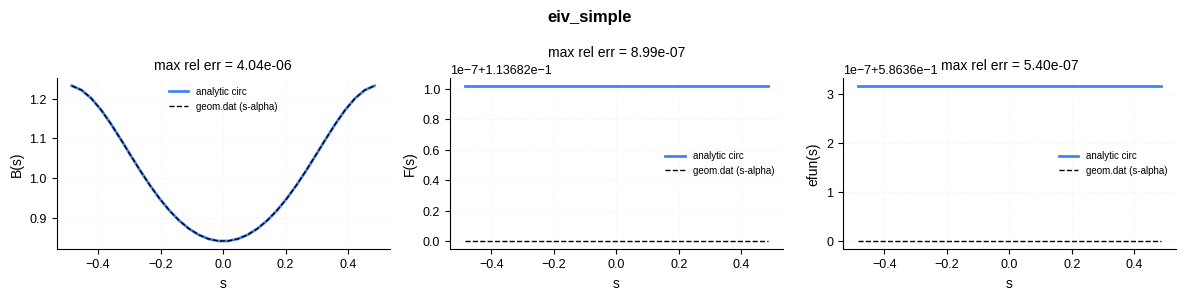

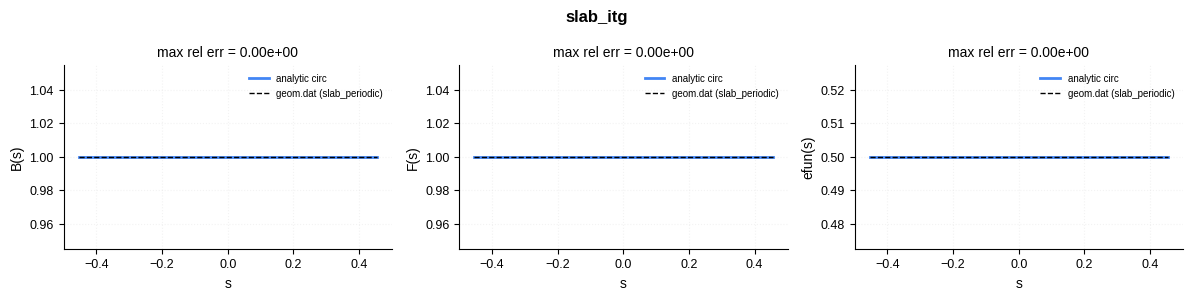

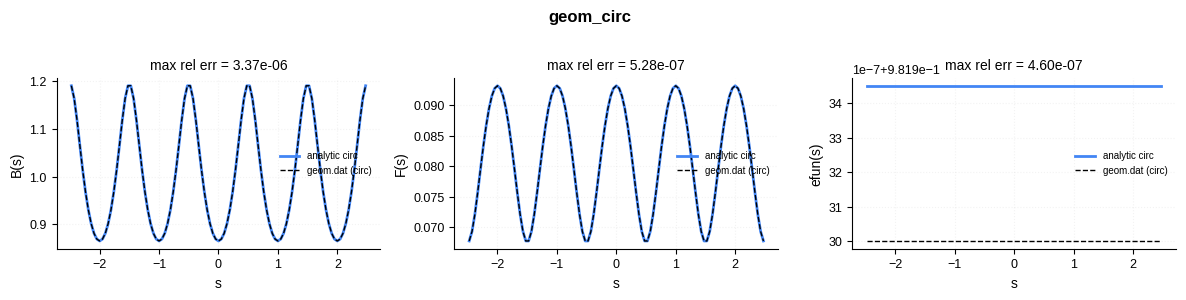

skipping sourcetime: no geom.dat


In [6]:
for case_name, (geometry, params) in built.items():
    geom_dat_path = os.path.join(GKW_CASES, case_name, "reference", "geom.dat")
    if not os.path.exists(geom_dat_path):
        print(f"skipping {case_name}: no geom.dat")
        continue

    gd = load_geom_dat_file(geom_dat_path)
    sgrid = np.asarray(geometry["sgrid"])
    gt = geom_type(case_name)

    fields = [("bn", "bn", "B(s)"), ("F", "ffun", "F(s)"), ("E_eps_zeta", "efun", "efun(s)")]
    fig, axes = plt.subplots(1, len(fields), figsize=(4 * len(fields), 3))

    for ax, (gd_key, geom_key, label) in zip(axes, fields):
        ref = np.asarray(gd.get(gd_key, []))
        comp = np.asarray(geometry[geom_key])
        if gd_key == "E_eps_zeta":
            comp = -comp
        if len(ref) != len(sgrid):
            ax.text(0.5, 0.5, "shape mismatch", ha="center", transform=ax.transAxes)
            continue
        max_rel = np.max(np.abs(ref - comp)) / (np.max(np.abs(ref)) + 1e-30)
        ax.plot(sgrid, comp, "-", color=JAX_COLORS["blue"], lw=2, label="analytic circ")
        ax.plot(sgrid, ref, "k--", lw=1, label=f"geom.dat ({gt})")
        ax.set_ylabel(label)
        ax.set_xlabel("s")
        ax.set_title(f"max rel err = {max_rel:.2e}")
        ax.legend(frameon=False, fontsize=7)
        ax.grid(True)

    fig.suptitle(case_name, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"figs/geom_{case_name}.pdf")
    plt.show()

---
# 5. Appendix: GKW Standard Test Reference Data

Growth rate and flux traces from GKW standard tests in `tests/data/gkw_cases/`.
These are the ground-truth targets. Miller cases shown for completeness but not
yet runnable in gyaradax.


eiv_simple: 1 windows, t=[1.0, 1.0]
  final growth = 1.81889e-01


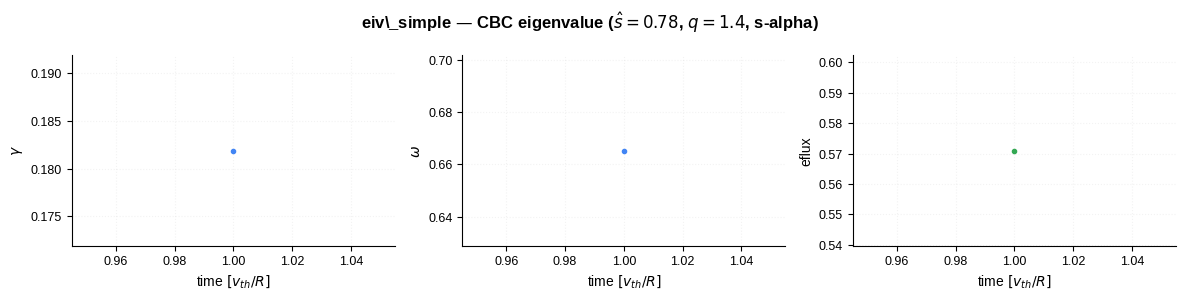


slab_itg: 20 windows, t=[5.0, 100.0]
  final growth = 7.25758e-02


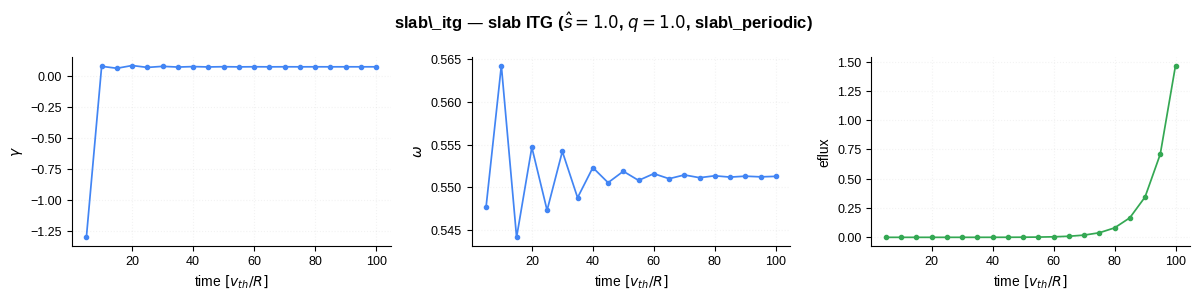


geom_circ: 10 windows, t=[0.0, 0.1]
  final growth = -1.61359e+01


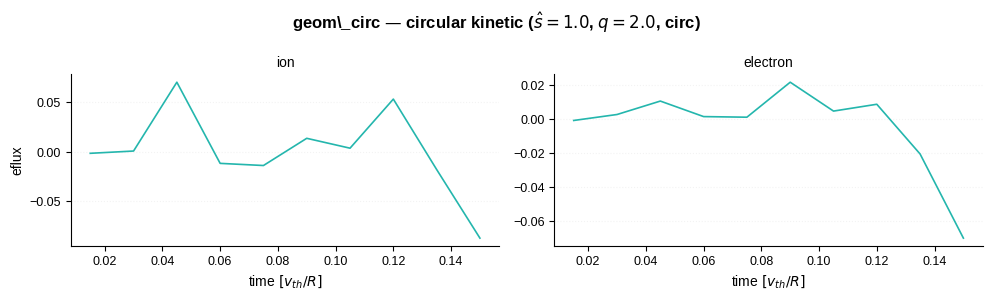


sourcetime: mean eflux=3.571e-05, mean vflux=-2.704e-06

miller_mb: 5 windows, t=[1.0, 5.0]
  final growth = 1.45653e-01


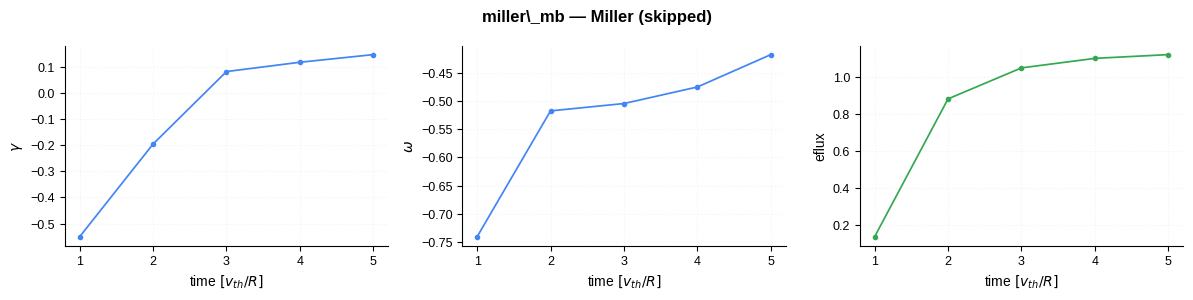


kinetic_elec: 70 windows, t=[1.2, 84.0]
  final growth = 1.24839e-01


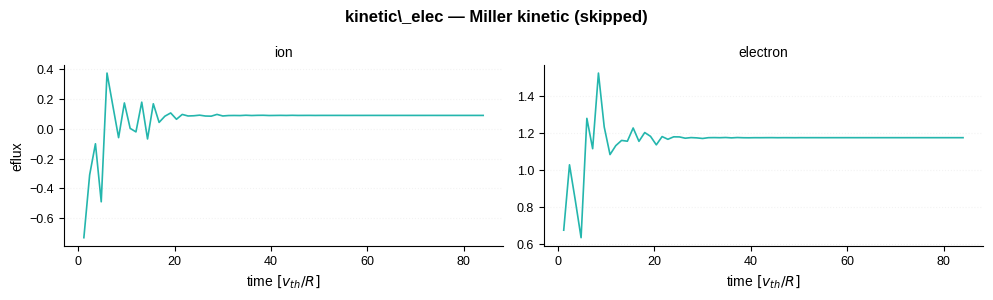

In [7]:
REF_CASES = {
    "eiv_simple": {"title": r"eiv\_simple — CBC eigenvalue ($\hat{s}=0.78$, $q=1.4$, s-alpha)"},
    "slab_itg": {"title": r"slab\_itg — slab ITG ($\hat{s}=1.0$, $q=1.0$, slab\_periodic)"},
    "geom_circ": {"title": r"geom\_circ — circular kinetic ($\hat{s}=1.0$, $q=2.0$, circ)"},
    "sourcetime": {"title": r"sourcetime — nonlinear CBC ($\hat{s}=0.78$, $q=1.4$, circ)"},
    "miller_mb": {"title": r"miller\_mb — Miller (skipped)"},
    "kinetic_elec": {"title": r"kinetic\_elec — Miller kinetic (skipped)"},
}

for case_name, info in REF_CASES.items():
    ref_dir = os.path.join(GKW_CASES, case_name, "reference")
    time_path = os.path.join(ref_dir, "time.dat")
    flux_path = os.path.join(ref_dir, "fluxes.dat")

    if not os.path.exists(time_path) or not os.path.exists(flux_path):
        # sourcetime has different files
        eflux_path = os.path.join(ref_dir, "eflux_es.dat")
        if os.path.exists(eflux_path):
            src_eflux = np.loadtxt(eflux_path)
            src_vflux = np.loadtxt(os.path.join(ref_dir, "vflux_es.dat"))
            print(
                f"\n{case_name}: mean eflux={np.mean(src_eflux):.3e}, mean vflux={np.mean(src_vflux):.3e}"
            )
        else:
            print(f"skipping {case_name}: no reference data")
        continue

    ref_time = np.loadtxt(time_path)
    ref_fluxes = np.loadtxt(flux_path)
    if ref_time.ndim == 1:
        ref_time = ref_time.reshape(1, -1)
    if ref_fluxes.ndim == 1:
        ref_fluxes = ref_fluxes.reshape(1, -1)
    t = ref_time[:, 0]

    n_flux_cols = ref_fluxes.shape[1]
    is_kinetic = n_flux_cols >= 6

    print(f"\n{case_name}: {len(t)} windows, t=[{t[0]:.1f}, {t[-1]:.1f}]")
    if ref_time.shape[1] >= 2:
        print(f"  final growth = {ref_time[-1, 1]:.5e}")

    if is_kinetic:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)
        axes[0].plot(t, ref_fluxes[:, 1], color=SPECIES_COLORS[0], lw=1.2)
        axes[0].set_ylabel("eflux")
        axes[0].set_title("ion")
        axes[0].grid(True, axis="y")
        axes[1].plot(t, ref_fluxes[:, 4], color=SPECIES_COLORS[1], lw=1.2)
        axes[1].set_title("electron")
        axes[1].grid(True, axis="y")
        for ax in axes:
            ax.set_xlabel(r"time $[v_{th}/R]$")
    else:
        ncols = min(3, ref_time.shape[1])
        fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3))
        if ncols == 1:
            axes = [axes]
        labels_y = [r"$\gamma$", r"$\omega$", "eflux"]
        for i, ax in enumerate(axes):
            if i < 2 and ref_time.shape[1] > i + 1:
                ax.plot(t, ref_time[:, i + 1], "o-", color=JAX_COLORS["blue"], ms=3)
                ax.set_ylabel(labels_y[i])
            elif i == 2:
                ax.plot(t, ref_fluxes[:, 1], "o-", color=JAX_COLORS["green"], ms=3)
                ax.set_ylabel("eflux")
            ax.set_xlabel(r"time $[v_{th}/R]$")
            ax.grid(True)

    fig.suptitle(info["title"], fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"figs/gkw_ref_{case_name}.pdf")
    plt.show()